## Classifier improvements

swap AdaBoost for histogram-based gradient boosting, validate with 10-fold cross-validation, then run the Punzi scan on the new classifier. this notebook is self-contained — it re-runs the same background fit + toy MC as `mass_fit.ipynb` at its own working point to quote the improved discovery time.

same 7 raw inputs as `bdt.ipynb` (MASS excluded), no feature engineering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
import os
from sklearn.model_selection import KFold
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

os.makedirs("../plots", exist_ok=True)

In [2]:
features  = ["PT1", "PT2", "P1", "P2", "TotalPT", "VertexChisq", "Isolation", "MASS"]
features7 = [f for f in features if f != "MASS"]

signal = pd.read_csv("../data/signal_Bs2MuMu.txt", sep=r"\s+", header=None, names=features)
background = pd.read_csv("../data/background_combinatorial.txt", sep=r"\s+", header=None, names=features)
signal = signal.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
background = background.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

X = pd.concat([signal[features7], background[features7]], axis=0).reset_index(drop=True)
y = np.concatenate([np.ones(len(signal)), np.zeros(len(background))])

In [3]:
def make_adaboost():
    base = DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42)
    return AdaBoostClassifier(estimator=base, n_estimators=100, learning_rate=0.5, random_state=42)

def make_gradboost():
    return HistGradientBoostingClassifier(max_depth=4, max_iter=200, learning_rate=0.1,
                                          min_samples_leaf=50, random_state=42)

cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}
for name, factory in [("AdaBoost", make_adaboost), ("GradBoost", make_gradboost)]:
    accs = []
    for train_idx, test_idx in cv.split(X):
        clf = factory()
        clf.fit(X.iloc[train_idx], y[train_idx])
        accs.append(accuracy_score(y[test_idx], clf.predict(X.iloc[test_idx])))
    cv_results[name] = {"folds": [float(a) for a in accs],
                        "mean": float(np.mean(accs)),
                        "std":  float(np.std(accs))}
    print(f"{name:10s}: {np.mean(accs):.4f} +/- {np.std(accs):.4f}")

AdaBoost  : 0.9287 +/- 0.0065


GradBoost : 0.9708 +/- 0.0041


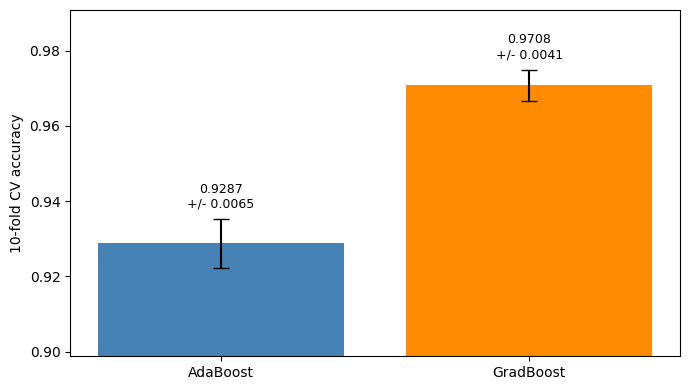

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(cv_results.keys())
means = [cv_results[n]["mean"] for n in names]
stds  = [cv_results[n]["std"]  for n in names]
x = np.arange(len(names))
ax.bar(x, means, yerr=stds, capsize=6, color=["steelblue", "darkorange"])
for xi, m, s in zip(x, means, stds):
    ax.text(xi, m + s + 0.003, f"{m:.4f}\n+/- {s:.4f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(min(means) - 0.03, max(means) + 0.02)
ax.set_ylabel("10-fold CV accuracy")
plt.tight_layout()
plt.savefig("../plots/cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Punzi scan on the improved model

same FOM scan as in `punzi_fom.ipynb`, but on GradBoost trained on the full sample.

improved Punzi: t=0.957  sig_eff=0.7082  bkg_eff=0.0012


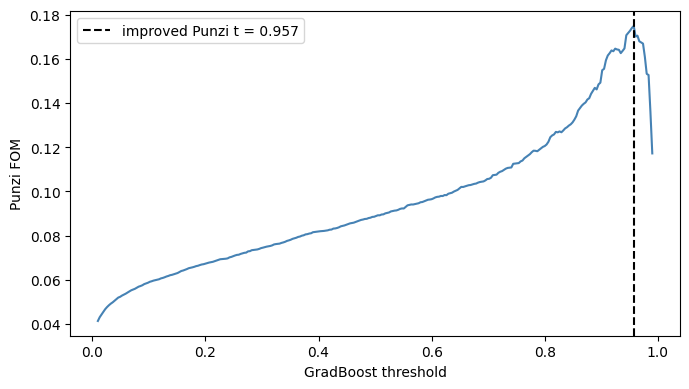

In [5]:
gb = make_gradboost()
gb.fit(X, y)
scores_sig = gb.predict_proba(signal[features7])[:, 1]
scores_bkg = gb.predict_proba(background[features7])[:, 1]

N_BKG_YEAR = 2000
n_sigma = 5.0
bkg_eff_floor = 1.0 / len(background)

thresholds = np.linspace(0.01, 0.99, 300)
fom_vals, sig_eff_scan, bkg_eff_scan = [], [], []
for t in thresholds:
    eps_s = (scores_sig >= t).mean()
    eps_b = max((scores_bkg >= t).mean(), bkg_eff_floor)
    B = N_BKG_YEAR * eps_b
    fom_vals.append(eps_s / (n_sigma/2 + np.sqrt(B)))
    sig_eff_scan.append(eps_s); bkg_eff_scan.append(eps_b)
fom_vals = np.array(fom_vals); sig_eff_scan = np.array(sig_eff_scan); bkg_eff_scan = np.array(bkg_eff_scan)

i_fom = int(np.argmax(fom_vals))
thr_punzi_imp = float(thresholds[i_fom])
sig_eff_imp_punzi = float(sig_eff_scan[i_fom])
bkg_eff_imp_punzi = float(bkg_eff_scan[i_fom])
print(f"improved Punzi: t={thr_punzi_imp:.3f}  sig_eff={sig_eff_imp_punzi:.4f}  bkg_eff={bkg_eff_imp_punzi:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, fom_vals, color="steelblue")
ax.axvline(thr_punzi_imp, color="black", linestyle="--",
           label=f"improved Punzi t = {thr_punzi_imp:.3f}")
ax.set_xlabel("GradBoost threshold"); ax.set_ylabel("Punzi FOM"); ax.legend()
plt.tight_layout()
plt.savefig("../plots/punzi_improved.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
with open("../improved_model.pkl", "wb") as fh:
    pickle.dump(gb, fh)

improved = {
    "classifier": "HistGradientBoostingClassifier",
    "features": features7,
    "cv_results": cv_results,
    "improved_punzi_threshold": thr_punzi_imp,
    "signal_efficiency_improved_punzi": sig_eff_imp_punzi,
    "background_efficiency_improved_punzi": bkg_eff_imp_punzi,
}
with open("../improved_results.json", "w") as fh:
    json.dump(improved, fh, indent=2)
print("saved improved_model.pkl and improved_results.json")

saved improved_model.pkl and improved_results.json


### Discovery time at the improved Punzi working point

self-contained toy MC at the GradBoost + Punzi WP, using the same procedure as `mass_fit.ipynb`.

In [7]:
from scipy.optimize import minimize
from scipy.stats import norm

bkg_mass = background["MASS"].to_numpy()
MASS_LO, MASS_HI = 4.0, 6.0
MU_SIG, SIG_SIG = 5.0, 0.03

def exp_pdf(m, lam):
    return np.exp(-lam*m) / ((np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))/lam)

def nll_bkg(params, masses):
    lam = params[0]
    if lam <= 0: return 1e10
    return -np.sum(np.log(exp_pdf(masses, lam)))

lam_fit = float(minimize(nll_bkg, x0=[0.5], args=(bkg_mass,), method="Nelder-Mead").x[0])

def sample_exp(lam, n, rng):
    u = rng.uniform(0, 1, size=n)
    return -np.log(np.exp(-lam*MASS_LO) - u*(np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))) / lam

def gen_toy(ns_mean, nb_mean, lam, rng):
    m = np.concatenate([
        rng.normal(MU_SIG, SIG_SIG, rng.poisson(ns_mean)),
        sample_exp(lam, rng.poisson(nb_mean), rng),
    ])
    return m[(m >= MASS_LO) & (m <= MASS_HI)]

def composite_pdf(m, fs, lam):
    return fs * norm.pdf(m, MU_SIG, SIG_SIG) + (1-fs) * exp_pdf(m, lam)

def nll_comp(params, masses):
    fs, lam = params
    if fs < 0 or fs > 1 or lam <= 0: return 1e10
    v = composite_pdf(masses, fs, lam)
    if np.any(v <= 0): return 1e10
    return -np.sum(np.log(v))

def fit_toy(masses):
    r = minimize(nll_comp, x0=[0.02, lam_fit], args=(masses,), method="Nelder-Mead",
                 options={"xatol":1e-5, "fatol":1e-5, "maxiter":5000})
    return float(r.fun)

def fit_bkg(masses):
    r = minimize(nll_bkg, x0=[lam_fit], args=(masses,), method="Nelder-Mead")
    return float(r.fun)

def run_significances(T, n_toys, rng):
    ns, nb = 50*sig_eff_imp_punzi*T, N_BKG_YEAR*bkg_eff_imp_punzi*T
    sigs = []
    for _ in range(n_toys):
        toy = gen_toy(ns, nb, lam_fit, rng)
        nll1 = fit_toy(toy); nll0 = fit_bkg(toy)
        sigs.append(np.sqrt(max(0.0, 2*(nll0 - nll1))))
    return np.array(sigs)

rng = np.random.default_rng(42)
z_1yr = run_significances(1.0, 1000, rng)
med_Z = float(np.median(z_1yr))
print(f"improved Punzi 1-yr median Z = {med_Z:.2f}, frac > 5 sigma = {(z_1yr>5).mean():.3f}")

durations = np.round(np.arange(0.1, 1.55, 0.1), 1)
probs = np.array([(run_significances(T, 300, rng) > 5).mean() for T in durations])
for T, p in zip(durations, probs):
    print(f"T = {T:.1f} yr  P(>5 sigma) = {p:.3f}")
idx = np.where(probs >= 0.95)[0]
T95 = float(durations[idx[0]]) if len(idx) else None
print(f"T95 (improved Punzi) = {T95} yr")

/sessions/nice-friendly-bohr/tmp/ipykernel_257/868615841.py:9: RuntimeWarning: invalid value encountered in divide
  return np.exp(-lam*m) / ((np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))/lam)
/sessions/nice-friendly-bohr/tmp/ipykernel_257/868615841.py:9: RuntimeWarning: divide by zero encountered in divide
  return np.exp(-lam*m) / ((np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))/lam)


improved Punzi 1-yr median Z = 13.48, frac > 5 sigma = 1.000


T = 0.1 yr  P(>5 sigma) = 0.283
T = 0.2 yr  P(>5 sigma) = 0.790
T = 0.3 yr  P(>5 sigma) = 0.970
T = 0.4 yr  P(>5 sigma) = 0.993
T = 0.5 yr  P(>5 sigma) = 1.000
T = 0.6 yr  P(>5 sigma) = 1.000
T = 0.7 yr  P(>5 sigma) = 1.000
T = 0.8 yr  P(>5 sigma) = 1.000
T = 0.9 yr  P(>5 sigma) = 1.000
T = 1.0 yr  P(>5 sigma) = 1.000
T = 1.1 yr  P(>5 sigma) = 1.000
T = 1.2 yr  P(>5 sigma) = 1.000
T = 1.3 yr  P(>5 sigma) = 1.000
T = 1.4 yr  P(>5 sigma) = 1.000
T = 1.5 yr  P(>5 sigma) = 1.000
T95 (improved Punzi) = 0.3 yr


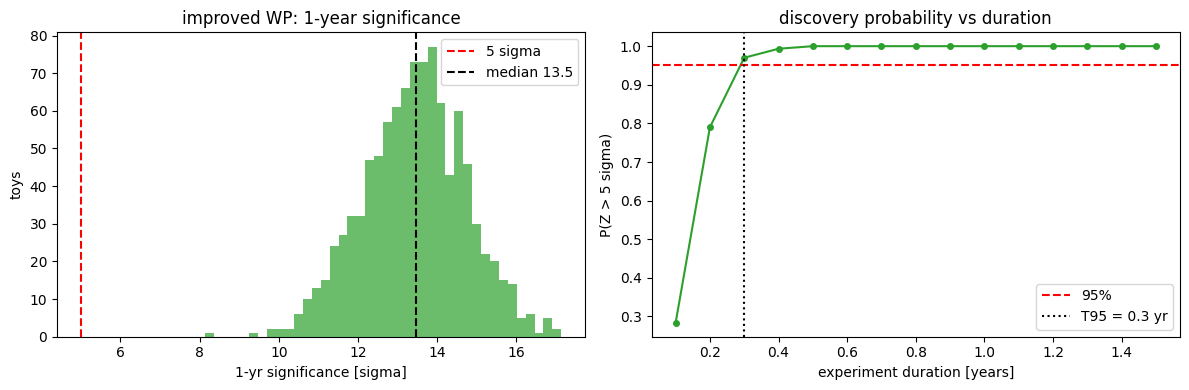

saved improved_results.json with discovery-time numbers


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(z_1yr, bins=40, alpha=0.7, color="#2CA02C")
ax.axvline(5, color="red", linestyle="--", label="5 sigma")
ax.axvline(med_Z, color="black", linestyle="--", label=f"median {med_Z:.1f}")
ax.set_xlabel("1-yr significance [sigma]"); ax.set_ylabel("toys"); ax.legend()
ax.set_title("improved WP: 1-year significance")

ax = axes[1]
ax.plot(durations, probs, marker="o", markersize=4, color="#2CA02C")
ax.axhline(0.95, color="red", linestyle="--", label="95%")
if T95 is not None:
    ax.axvline(T95, color="black", linestyle=":", label=f"T95 = {T95} yr")
ax.set_xlabel("experiment duration [years]"); ax.set_ylabel("P(Z > 5 sigma)")
ax.legend(); ax.set_title("discovery probability vs duration")
plt.tight_layout()
plt.savefig("../plots/discovery_duration_improved.png", dpi=150, bbox_inches="tight")
plt.show()

improved["median_significance_1yr_improved_punzi"] = med_Z
improved["T95_improved_punzi_years"] = T95
with open("../improved_results.json", "w") as fh:
    json.dump(improved, fh, indent=2)
print("saved improved_results.json with discovery-time numbers")